# 38.2 · Scaled dot-product attention

CPU · Python 3.11–3.13 · seeded teaching experiment

[Open in Google Colab](https://colab.research.google.com/) — use the [ZIP setup workflow](../../docs/colab.md). No model or dataset downloads occur in this notebook.

## Learning Objectives

- Explain scaled dot-product attention using the chapter's assumptions.
- Translate the worked equation into Python and inspect an implementation.
- Run, visualize and critique a reproducible experiment.

## Prerequisites

[02 · Mathematics](../../02-mathematics-for-computer-vision/README.md), [23 · CNN fundamentals](../../23-cnn-fundamentals/README.md), [24 · PyTorch](../../24-pytorch-for-computer-vision/README.md)

Install the repository before opening this notebook: `python -m pip install -e ".[notebooks,deep,api]"`. The deep/API extras are needed only by chapters that use them.

## 1. Introduction

Attention is a data-dependent weighted average. Imagine asking a question of every item, scoring how relevant each item is, and combining the information from the most relevant items. Queries, keys and values are learned projections that make this comparison trainable.

## 2. Intuition

Multiply queries by transposed keys to form a score matrix, divide by the square root of key dimension, apply a row-wise softmax and multiply by values. Scaling controls score magnitude as dimension grows. The NumPy implementation uses stable softmax and is compared numerically with PyTorch.

In [1]:
import inspect
import json
import platform
from importlib.metadata import version

import cv2
import numpy as np
from IPython.display import Code, display

from cvzero.course.runner import lab_function, run

CHAPTER = 38
LESSON = 1
SEED = 42
AMOUNT = 1.0
print(
    {
        "python": platform.python_version(),
        "numpy": version("numpy"),
        "opencv": cv2.__version__,
        "device": "cpu",
        "seed": SEED,
    }
)

{'python': '3.12.14', 'numpy': '2.3.5', 'opencv': '4.14.0', 'device': 'cpu', 'seed': 42}


## 3. Mathematical Foundation

$$
Attention(Q,K,V)=softmax(QK^T/\sqrt{d_k})V
$$

Q and K are query/key matrices, V contains values and dk is key width. Softmax acts over keys for each query. Equal scores over two values [2,6] yield their mean 4.

Read the symbols aloud, predict the numerical result, and only then execute the worked example.

## 4. Visual Explanation

The chapter preview shows an actual baseline run. Read every panel title before interpreting color or brightness; some panels show a mask, an error, or a matrix rather than a photograph.

![Measured chapter baseline](../assets/lab-preview.png)

## 5. Basic Implementation

This small calculation isolates the equation from the larger pipeline. Change one number and predict its effect before rerunning.

In [2]:
scores = np.array([0.0, 0.0])
weights = np.exp(scores) / np.exp(scores).sum()
values = np.array([2.0, 6.0])
output = weights @ values
assert np.isclose(output, 4)
print(weights, output)

[0.5 0.5] 4.0


## 6. OpenCV Implementation

The relevant library is selected by the problem: OpenCV for image operations and geometry, scikit-learn for classical learning, PyTorch for differentiable models, and FastAPI for service contracts. OpenCV handles image arrays where it is useful; it does not supply every advanced model.

The reference returns both weighted values and the attention matrix, allowing row sums and masked entries to be inspected. Framework comparison uses matching inputs and mask conventions.

The lab function below calls the actual implementation. Inspect its source to see preprocessing, fixed hyperparameters and reported metrics.

In [3]:
display(Code(inspect.getsource(lab_function(CHAPTER)), language="python"))
result = run(CHAPTER, lesson=LESSON, seed=SEED, amount=AMOUNT)
print(json.dumps(result.metrics, indent=2))
print(result.notes)

def attention_lab(lesson, seed, amount):
    rng = configure(seed)
    q = rng.normal(size=(6, 4))
    k = rng.normal(size=(6, 4))
    v = rng.normal(size=(6, 3))
    mask = np.tril(np.ones((6, 6), bool)) if lesson == 1 else None
    output, weights = n.attention(q * amount, k, v, mask)
    qt, kt, vt = [torch.tensor(a, dtype=torch.float64)[None, None] for a in (q * amount, k, v)]
    comparison = F.scaled_dot_product_attention(
        qt, kt, vt, attn_mask=None if mask is None else torch.tensor(mask)
    ).numpy()[0, 0]
    return Result(
        "38 · Query, key, value and scaled attention",
        {"Attention weights (rows sum to 1)": weights, "Weighted value output": output},
        metrics={
            "row_sum_max_error": float(abs(weights.sum(1) - 1).max()),
            "pytorch_max_error": float(abs(output - comparison).max()),
            "causal_mask": lesson == 1,
        },
        notes="A causal mask is demonstrated for sequence reasoning; a standard ViT uses bidirectional patch attention.",
    )

{
  "row_sum_max_error": 1.1102230246251565e-16,
  "pytorch_max_error": 1.1102230246251565e-16,
  "causal_mask": true
}
A causal mask is demonstrated for sequence reasoning; a standard ViT uses bidirectional patch attention.


## 7. From-Scratch Implementation

Read the following reusable reference implementation line by line. Identify input shapes, the main update or reduction, and the boundary/invalid-input policy. Its source lives in `src/cvzero/course/numerics.py`; notebooks reuse it so fixes apply everywhere. Optimized libraries are compared where matching behavior is meaningful.

In [4]:
from cvzero.course.numerics import attention

display(Code(inspect.getsource(attention), language="python"))

def attention(q, k, v, mask=None):
    """Scaled dot-product attention, optionally masking prohibited pairs."""
    scores = np.asarray(q) @ np.asarray(k).T / np.sqrt(np.asarray(q).shape[-1])
    if mask is not None:
        mask = np.broadcast_to(np.asarray(mask, bool), scores.shape)
        if not mask.any(axis=-1).all():
            raise ValueError("Every query must have at least one allowed key.")
        scores = np.where(mask, scores, -np.inf)
    weights = softmax(scores)
    return weights @ v, weights

## 8. Experiment

Scale query/key magnitudes and inspect whether attention becomes peaked. Apply a triangular mask and verify forbidden weights are zero.

The run configuration is defined above. `lesson` selects the chapter experiment, `seed` fixes generated data or initialization, and `amount` controls the active experiment's perturbation when supported. Consult the displayed function before changing it: a fixed mathematical example may deliberately ignore a random seed or perturbation. Keep all other settings fixed when testing one hypothesis.

In [5]:
# A second independent seed checks sensitivity; fixed examples may remain identical.
repeat = run(CHAPTER, lesson=LESSON, seed=SEED + 1, amount=AMOUNT)
print(json.dumps({"baseline": result.metrics, "second_seed": repeat.metrics}, indent=2))

{
  "baseline": {
    "row_sum_max_error": 1.1102230246251565e-16,
    "pytorch_max_error": 1.1102230246251565e-16,
    "causal_mask": true
  },
  "second_seed": {
    "row_sum_max_error": 2.220446049250313e-16,
    "pytorch_max_error": 2.220446049250313e-16,
    "causal_mask": true
  }
}


## 9. Visualization

These figures are generated by the current run. The second plot uses the second seed. Compare the numerical report with the visible result; a single scalar rarely explains every failure.

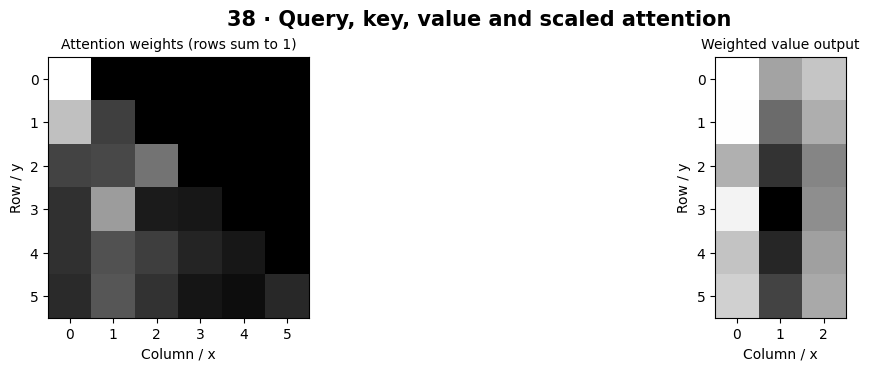

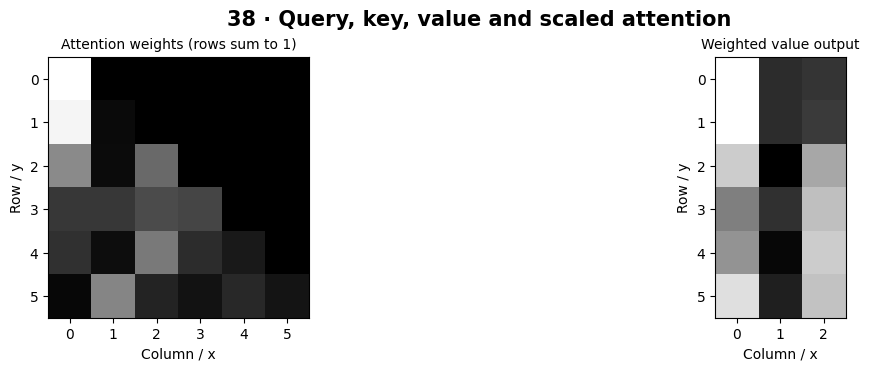

In [6]:
display(result.plot())
display(repeat.plot())

## 10. Real-World Application

The chapter mini project is **Attention Inspector**. Investigate the attention mechanism introduced in Chapter 37. Start with the generated data so expected geometry or labels are known, then use a separately documented real dataset. Do not transfer synthetic metrics to a real deployment claim.

## 11. Common Mistakes

A softmax over the wrong axis can still produce plausible array shapes. Attention weights are not automatically causal explanations of predictions.

Check shape, dtype, units, split and coordinate conventions before tuning an algorithm.

## 12. Exercises

- **Easy:** Reproduce the worked numerical example by hand and add a second case.
- **Medium:** Scale query/key magnitudes and inspect whether attention becomes peaked. Apply a triangular mask and verify forbidden weights are zero.
- **Hard:** Create a failure case for one assumption stated in this lesson and propose a measurable remedy.

## 13. Challenge

Implement multi-head attention by splitting and recombining dimensions, then compare outputs and gradients with a library module.

Write acceptance criteria before coding. No challenge solution is included beside the question.

## 14. Summary

Multiply queries by transposed keys to form a score matrix, divide by the square root of key dimension, apply a row-wise softmax and multiply by values. Scaling controls score magnitude as dimension grows. The NumPy implementation uses stable softmax and is compared numerically with PyTorch.

**Checkpoint:** explain the mechanism, implement a small case, modify one parameter, debug a failure and apply it to a new example. Record evidence for all five.

## 15. Next Step

Continue with **Masks, heads and efficient attention** in this chapter.

[Primary reference](https://arxiv.org/abs/1706.03762) · [Chapter exercises](../exercises/beginner.md) · [Mini project](../mini-project/README.md)